In [30]:
import sqlite3 as db

import pandas as pd
from pycaret.classification import *

from features import label_encoder
from utilities import get_path, read_data_from_database

In [31]:
pd.options.display.max_columns = None  # Remove "dots" from display when printing dataframes

In [32]:
PATH = get_path(1)
DATABASE_FOLDER = PATH + 'data/preprocessing/BANCO_BOGOTA.db'

In [33]:
df_train = read_data_from_database(DATABASE_FOLDER, 'prep_train_data')
df_test = read_data_from_database(DATABASE_FOLDER, 'prep_test_data')

In [34]:
df_train.head()

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,Dia,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,1,57,servicios,casado,bachillerato,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
1,2,37,servicios,casado,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
2,3,40,administrador negocio,casado,primaria,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
3,4,56,servicios,casado,bachillerato,0.0,0.0,1.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
4,7,25,servicios,soltero,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0


# Label encoder

In [35]:
labels_to_encoders_name = {
    'Tipo_Trabajo':'Tipo_Trabajo_ENC',
    'Estado_Civil':'Estado_Civil_ENC',
    'Educacion':'Educacion_ENC',    
    'Contacto':'Contacto_ENC',
    'Mes':'Mes_ENC',
    'Dia':'Dia_ENC',
    'Resultado_Anterior':'Resultado_Anterior_ENC'
    }

for var_encoder, encoder_name in labels_to_encoders_name.items():
    label_encoder(var_encoder, encoder_name, df_train)

In [36]:
df_train[[
    'Tipo_Trabajo', 'Tipo_Trabajo_ENC', 'Estado_Civil', 'Estado_Civil_ENC',
    'Educacion', 'Educacion_ENC', 'Contacto', 'Contacto_ENC', 'Mes', 'Mes_ENC',
    'Dia', 'Dia_ENC','Resultado_Anterior', 'Resultado_Anterior_ENC'
    ]].sample(n=10).head(10)

,Tipo_Trabajo,Tipo_Trabajo_ENC,Estado_Civil,Estado_Civil_ENC,Educacion,Educacion_ENC,Contacto,Contacto_ENC,Mes,Mes_ENC,Dia,Dia_ENC,Resultado_Anterior,Resultado_Anterior_ENC
14746,servicios,7,divorciado,1,bachillerato,0,celular,0,nov,7,mié,3,sin contacto,2
2244,administrador negocio,0,casado,0,pregrado,5,telefono fijo,1,may,6,lun,1,sin contacto,2
1612,empleado,3,casado,0,preescolar,4,telefono fijo,1,may,6,mié,3,sin contacto,2
18603,servicios,7,casado,0,bachillerato,0,telefono fijo,1,may,6,mar,2,sin contacto,2
2575,servicios,7,casado,0,bachillerato,0,telefono fijo,1,may,6,mar,2,sin contacto,2
11349,administrador negocio,0,soltero,2,pregrado,5,celular,0,ago,1,lun,1,sin contacto,2
7728,empleado,3,divorciado,1,preescolar,4,celular,0,jul,3,jue,0,sin contacto,2
20195,tecnico,8,casado,0,pregrado,5,celular,0,may,6,lun,1,satisfactorio,1
4156,empleado,3,soltero,2,bachillerato incompleto,1,telefono fijo,1,may,6,jue,0,sin contacto,2
16067,vendedor ambulante,9,divorciado,1,bachillerato incompleto,1,celular,0,abr,0,mié,3,fallido,0


# Auto Machine Learning

In [37]:
df_new = df_train[[
    'Edad', 'Tipo_Trabajo_ENC', 'Estado_Civil_ENC', 'Educacion_ENC', 
    'mora', 'Vivienda', 'Consumo', 'Contacto_ENC', 'Mes_ENC', 'Dia_ENC', 
    'Campana', 'Dias_Ultima_Camp', 'No_Contactos', 'Resultado_Anterior_ENC',
    'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed',
    'y'
    ]].copy()

df_new.head()

,Edad,Tipo_Trabajo_ENC,Estado_Civil_ENC,Educacion_ENC,mora,Vivienda,Consumo,Contacto_ENC,Mes_ENC,Dia_ENC,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior_ENC,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,57,7,0,0,0.0,0.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
1,37,7,0,0,0.0,1.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
2,40,0,0,6,0.0,0.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
3,56,7,0,0,0.0,0.0,1.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0
4,25,7,2,0,0.0,1.0,0.0,1,6,1,1,-1,0,2,1.1,93994.0,-36.4,4857.0,5191,0


In [38]:
data = df_new.sample(frac=0.8, random_state=0)
data_unseen = df_train.drop(data.index)

In [39]:
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print(f'Datos para modelar: {data.shape}; y datos para predecir: {data_unseen.shape}')

Datos para modelar: (18479, 20); y datos para predecir: (4620, 28)


In [40]:
model_setup = setup(data=data, target='y')

,Description,Value
0,Session id,4171
1,Target,y
2,Target type,Binary
3,Original data shape,"(18479, 20)"
4,Transformed data shape,"(18479, 30)"
5,Transformed train set shape,"(12935, 30)"
6,Transformed test set shape,"(5544, 30)"
7,Numeric features,17
8,Categorical features,2
9,Preprocess,True


In [41]:
models()  # Modelos suportados

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [42]:
best_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8966,0.7783,0.2030,0.6371,0.3060,0.2665,0.3186,0.0890
gbc,Gradient Boosting Classifier,0.8966,0.7862,0.2125,0.6344,0.3171,0.2761,0.3255,0.1980
ridge,Ridge Classifier,0.8945,0.7791,0.1676,0.6315,0.2637,0.2273,0.2869,0.0260
lightgbm,Light Gradient Boosting Machine,0.8937,0.7805,0.2445,0.5740,0.3419,0.2944,0.3267,0.1380
catboost,CatBoost Classifier,0.8926,0.7795,0.2357,0.5646,0.3313,0.2838,0.3165,3.6400
lr,Logistic Regression,0.8918,0.7677,0.1566,0.5831,0.2453,0.2081,0.2617,0.6790
rf,Random Forest Classifier,0.8908,0.7650,0.2568,0.5384,0.3469,0.2956,0.3202,0.1550
xgboost,Extreme Gradient Boosting,0.8899,0.7545,0.2677,0.5310,0.3547,0.3018,0.3236,0.1400
dummy,Dummy Classifier,0.8865,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0250
et,Extra Trees Classifier,0.8842,0.7469,0.2643,0.4825,0.3405,0.2831,0.2990,0.1540


In [43]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8964,0.7787,0.1905,0.6512,0.2947,0.2565,0.3141
1,0.8887,0.7630,0.1701,0.5319,0.2577,0.2145,0.2559
2,0.8980,0.7445,0.2245,0.6471,0.3333,0.2919,0.3405
3,0.8957,0.7594,0.1701,0.6579,0.2703,0.2345,0.2983
4,0.9065,0.7962,0.2721,0.7407,0.3980,0.3589,0.4124
5,0.8910,0.7689,0.1633,0.5714,0.2540,0.2143,0.2642
6,0.8987,0.7903,0.2517,0.6379,0.3610,0.3170,0.3579
7,0.8971,0.7787,0.2381,0.6250,0.3448,0.3010,0.3427
8,0.8925,0.7851,0.1233,0.6207,0.2057,0.1748,0.2430


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=4171)


In [44]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8964,0.7787,0.1905,0.6512,0.2947,0.2565,0.3141
1,0.8887,0.7630,0.1701,0.5319,0.2577,0.2145,0.2559
2,0.8980,0.7445,0.2245,0.6471,0.3333,0.2919,0.3405
3,0.8957,0.7594,0.1701,0.6579,0.2703,0.2345,0.2983
4,0.9065,0.7962,0.2721,0.7407,0.3980,0.3589,0.4124
5,0.8910,0.7689,0.1633,0.5714,0.2540,0.2143,0.2642
6,0.8987,0.7903,0.2517,0.6379,0.3610,0.3170,0.3579
7,0.8971,0.7787,0.2381,0.6250,0.3448,0.3010,0.3427
8,0.8925,0.7851,0.1233,0.6207,0.2057,0.1748,0.2430


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=4171)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8964,0.7769,0.1565,0.6970,0.2556,0.2232,0.2974
1,0.8949,0.7678,0.1429,0.6774,0.2360,0.2045,0.2784
2,0.8972,0.7305,0.1633,0.7059,0.2652,0.2324,0.3066
3,0.8957,0.7678,0.1497,0.6875,0.2458,0.2139,0.2880
4,0.9019,0.7932,0.1973,0.7632,0.3135,0.2799,0.3560
5,0.8902,0.7822,0.1088,0.5926,0.1839,0.1541,0.2203
6,0.9002,0.7873,0.2041,0.7143,0.3175,0.2811,0.3467
7,0.8971,0.7710,0.1905,0.6667,0.2963,0.2588,0.3192
8,0.8940,0.7666,0.1164,0.6800,0.1988,0.1715,0.2516


Fitting 10 folds for each of 10 candidates, totalling 100 fits


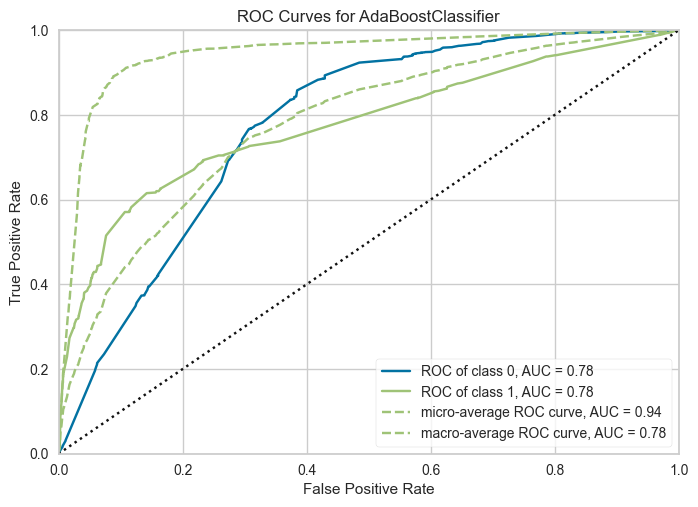

In [45]:
tuned_ada = tune_model(ada)
plot_model(tuned_ada, plot='auc')

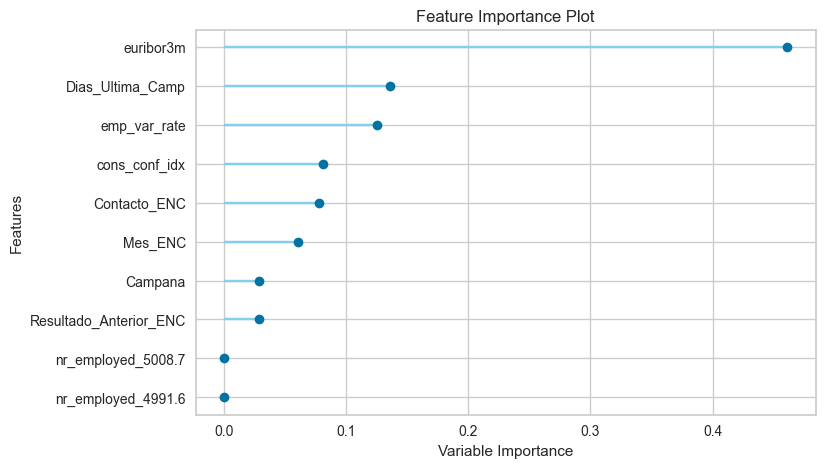

In [46]:
plot_model(tuned_ada, plot='feature')

In [47]:
unseen_predictions = predict_model(tuned_ada, data=data_unseen)
unseen_predictions[['y', 'prediction_label', 'prediction_score']].sample(n=25).head(25)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.9019,0.7927,0.1602,0.6695,0.2586,0.2267,0.2951


,y,prediction_label,prediction_score
647,0,0,0.8416
3703,0,0,0.7387
3453,0,0,0.7387
3320,0,0,0.7033
1116,0,0,0.8286
3182,0,0,0.7033
878,0,0,0.8416
2741,0,0,0.8259
229,0,0,0.8482
4587,1,0,0.5334


In [48]:
final_ada = finalize_model(tuned_ada)
print(final_ada)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Edad', 'Tipo_Trabajo_ENC',
                                             'Estado_Civil_ENC',
                                             'Educacion_ENC', 'mora',
                                             'Vivienda', 'Consumo',
                                             'Contacto_ENC', 'Mes_ENC',
                                             'Dia_ENC', 'Dias_Ultima_Camp',
                                             'No_Contactos',
                                             'Resultado_Anterior_ENC',
                                             'emp_var_rate', 'cons_price_idx',
                                             'cons_conf_idx', 'euribor3m']...
                 TransformerWrapper(exclude=None, include=['Campana'],
                                    transformer=TargetEncoder(cols=['Campana'],
         

# Save

In [49]:
save_model(final_ada, PATH + 'data/salida/ADA_model_02-05-2024')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Edad', 'Tipo_Trabajo_ENC',
                                              'Estado_Civil_ENC',
                                              'Educacion_ENC', 'mora',
                                              'Vivienda', 'Consumo',
                                              'Contacto_ENC', 'Mes_ENC',
                                              'Dia_ENC', 'Dias_Ultima_Camp',
                                              'No_Contactos',
                                              'Resultado_Anterior_ENC',
                                              'emp_var_rate', 'cons_price_idx',
                                              'cons_conf_idx', 'euribor3m']...
                  TransformerWrapper(exclude=None, include=['Campana'],
                                     transformer=TargetEncoder(cols=['Campa

# Deploy